# 📊 Sales Data Analysis - Exploratory Data Analysis
## 🏢 Business Context

This analysis simulates a retail company aiming to improve sales performance and profitability.

## 🎯 Business Questions
- Which products drive the most revenue and profit?
- What is the impact of returns on business performance?
- Are there data quality issues affecting decision-making?

## 🎯 Objective
Analyze sales performance and data quality to identify key issues and insights.

## 📁 Dataset
Sales dataset containing transactions, products, customers, and financial metrics.

## 🧠 Approach
- Data exploration
- Data quality assessment
- Initial insights


In [147]:
import os
os.listdir('/Users/dlf/Documents/PROJECT_BI_SALES_ANALYSIS/data') #Check for de raw data

['Sales_Dataset_2024 (1).xlsx', '.ipynb_checkpoints']

In [148]:
import pandas as pd
import numpy as np

In [149]:
df = pd.read_excel('/Users/dlf/Documents/PROJECT_BI_SALES_ANALYSIS/data/Sales_Dataset_2024 (1).xlsx')

In [150]:
df.head() #Show columns

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
0,2024-04-12,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634258,1908.365742
1,2024-12-14,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273
2,2024-09-27,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874
3,2024-04-16,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908
4,2024-03-12,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334


In [151]:
df.shape #Dimension of the matrix

(2000, 10)

In [152]:
df.columns

Index(['Date', 'Region', 'Product', 'Salesperson', 'Units_Sold', 'Unit_Price',
       'Category', 'Revenue', 'Cost', 'Profit'],
      dtype='object')

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       1961 non-null   object        
 2   Product      1960 non-null   object        
 3   Salesperson  1960 non-null   object        
 4   Units_Sold   1960 non-null   float64       
 5   Unit_Price   1960 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      1921 non-null   float64       
 8   Cost         1921 non-null   float64       
 9   Profit       1921 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB


## 🔍 Data Quality Analysis

### Observations:
- Checking for missing values
- Identifying inconsistent data
- Reviewing data types

In [154]:
df.isnull().sum() #Sumatory of nulls

Date            0
Region         39
Product        40
Salesperson    40
Units_Sold     40
Unit_Price     40
Category        0
Revenue        79
Cost           79
Profit         79
dtype: int64

### 🚨 Data Issues Identified

- Missing values in product category
- Some incomplete transaction records
- Potential data quality issues affecting analysis

### 🧠 Initial Decision

- Evaluate whether to remove or impute missing values
- Further investigation required

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.describe()

,Date,Units_Sold,Unit_Price,Revenue,Cost,Profit
count,2000,1960.000000,1960.000000,1921.000000,1921.000000,1921.000000
mean,2024-07-01 16:25:40.800000,10.089286,1062.118878,10785.823529,8065.726146,2720.097383
min,2024-01-01 00:00:00,-5.000000,-100.000000,-8975.000000,-7905.695724,-1069.304276
25%,2024-04-04 00:00:00,5.000000,592.500000,3597.000000,2665.613741,784.467841
50%,2024-07-01 00:00:00,10.000000,1073.500000,8268.000000,6014.593046,1928.596208
75%,2024-10-03 00:00:00,15.000000,1519.750000,16461.000000,12152.488896,3936.337721
max,2024-12-31 00:00:00,19.000000,1997.000000,37715.000000,31723.724915,14409.770718
std,NaN,5.601601,545.428034,8722.447605,6645.827102,2502.678468


## ✅ Summary

- Dataset loaded successfully
- Data quality issues identified
- Ready for cleaning and transformation phase

### 🚨 Data Issues Identified

- Negative values detected in Units_Sold, Unit_Price, Revenue, and Profit
- These may represent:
  - Data entry errors
  - Product returns or refunds


### 🧠 Hypothesis

Negative values likely correspond to returned products or financial adjustments.

Further validation required before cleaning.

### 🔍 Returns Identified

Negative values in Units_Sold, Revenue, and Profit were detected.

These are interpreted as product returns rather than data errors, as all financial fields are consistently negative.

Returns are retained in the dataset due to their impact on business performance.

In [157]:
df[df['Units_Sold'] < 0] #Are they refounds?

,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
697,2024-01-28,North,Printer,Hannah,-5.0,1795.0,Office,-8975.0,-7905.695724,-1069.304276
1243,2024-05-10,North,Laptop,Eva,-1.0,1093.0,Electronics,-1093.0,-700.858542,-392.141458
1864,2024-01-07,South,Printer,Charlie,-3.0,1140.0,Office,-3420.0,-2420.209124,-999.790876


# 🧼 Data Cleaning

In this section, data is cleaned and transformed to ensure consistency and reliability for analysis.

## 🚨 No Seller or Category Name Issue Identified

## 🧼 Seller names are correct

In [158]:
print("Raw Seller Values:")
print(df['Salesperson'].unique())
print("Raw Seller Values:")
print(df['Salesperson'].value_counts())

Raw Seller Values:
['Hannah' 'Eva' 'Bob' 'Charlie' 'Grace' nan 'Alice' 'David' 'Frank']
Raw Seller Values:
Salesperson
Grace      265
Hannah     256
David      256
Frank      252
Charlie    244
Eva        239
Bob        233
Alice      215
Name: count, dtype: int64


## 🧼 Category names are correct

In [159]:
print("Raw Category Values:")
print(df['Category'].unique())
print("Raw Category Values:")
print(df['Category'].value_counts())

Raw Category Values:
['Accessories' 'Office' 'Electronics']
Raw Category Values:
Category
Electronics    1013
Accessories     506
Office          481
Name: count, dtype: int64


## 🚨 Detected Nulls, and Product and Region Name Issue

## 🧼 Data Cleaning Process

### 1. Product Standardization
### 2. Region Standardization
### 3. Null Value Treatment
### 4. Invalid Records Removal

## 🚨 Product Name Issue Identified
- Some product names are not correct and not all Capitalized.
- Spelling error:
  - tabllet
  - MOBLIE
- Standardization is necessary.

In [160]:
print("Raw Product Values:")
print(df['Product'].unique())
print(df['Product'].value_counts())

Raw Product Values:
['Smartwatch' 'Monitor' 'Mobile' 'Headphones' 'Camera' 'Laptop' 'Printer'
 'Tablet' nan 'tabllet' 'MOBLIE' 'SMARTWATCH' 'headPhones' 'laptop']
Product
Tablet        263
Smartwatch    259
Laptop        259
Monitor       240
Camera        239
Headphones    234
Printer       229
Mobile        227
tabllet         2
MOBLIE          2
SMARTWATCH      2
headPhones      2
laptop          2
Name: count, dtype: int64


## 🧼 1.Product Name Standardization

In [161]:
# --- PRODUCT CLEANING ---

# 1. Normalize
df['Product'] = df['Product'].str.strip().str.lower()

# 2. Correct bad names
df['Product'] = df['Product'].replace({
    'tabllet': 'tablet',
    'moblie': 'mobile'
    })

# 3. Capitalize
df['Product'] = df['Product'].str.title()

# 4. Validation
print("Unique Products:")
print(df['Product'].value_counts())

Unique Products:
Product
Tablet        265
Smartwatch    261
Laptop        261
Monitor       240
Camera        239
Headphones    236
Mobile        229
Printer       229
Name: count, dtype: int64


## 🚨 Region Name Issue Identified
- Some region names are not correct and the not all Capitalized.
- Spelling error:
  - westt
  - Easst
- Standardization is necessary.

In [162]:
print("Raw Region Values:")
print(df['Region'].unique())
print(df['Region'].value_counts())

Raw Region Values:
['North' 'West' 'East' 'South' nan 'south' 'westt' 'Easst' 'NORTH' 'north']
Region
West     506
North    500
South    486
East     459
south      2
westt      2
Easst      2
NORTH      2
north      2
Name: count, dtype: int64


## 🧼 2. Region Name Standardization

In [163]:
# --- REGIONS CLEANING ---

# 1. Normalize
df['Region'] = df['Region'].str.strip().str.lower()

# 2. Correct bad names
df['Region'] = df['Region'].replace({
    'easst': 'east',
    'westt': 'west'
    })

# 3. Capitalize
df['Region'] = df['Region'].str.title()

# 4. Validation
print("Unique Regions:")
print(df['Region'].value_counts())

Unique Regions:
Region
West     508
North    504
South    488
East     461
Name: count, dtype: int64


## 🚨 Nulls Issue Identified
- There are nulls in these columns:
  - Region
  - Product
  - Salesperson
  - Units_Sold
  - Unit_Price
  - Revenue
  - Cost
  - Profit
- It is necessary to try to allocate values for not erase all incomplete data.

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       1961 non-null   object        
 2   Product      1960 non-null   object        
 3   Salesperson  1960 non-null   object        
 4   Units_Sold   1960 non-null   float64       
 5   Unit_Price   1960 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      1921 non-null   float64       
 8   Cost         1921 non-null   float64       
 9   Profit       1921 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB


### 🧠 Hypothesis Allocation of null Regions for Salesperson
A hypothesis was formulated to evaluate whether missing Regions values could be imputed based on observed patterns in the data.  

Some values of “Region” could be imputed in case a seller operates only in a specific region.

In [165]:
pd.crosstab(df['Salesperson'], df['Region'])

Region,East,North,South,West
Salesperson,,,,
Alice,55,50,44,63
Bob,49,71,57,51
Charlie,58,49,58,74
David,59,67,66,54
Eva,59,67,53,56
Frank,56,66,62,65
Grace,58,57,69,77
Hannah,59,68,69,57


## 🔍 Insight Allocation of null Regions for Salesperson

It seems that salespeople sell in all regions. Therefore, we cannot assign a region values to any salesperson.

### 🧠 Hypothesis Allocation of null Product for Salesperson
A hypothesis was formulated to evaluate whether missing Product values could be imputed based on observed patterns in the data.

Some values to “Product” could be imputed in case a seller operates only with a specific type of Product.

In [166]:
pd.crosstab(df['Salesperson'], df['Product'])

Product,Camera,Headphones,Laptop,Mobile,Monitor,Printer,Smartwatch,Tablet
Salesperson,,,,,,,,
Alice,18,30,26,24,29,21,36,28
Bob,31,32,27,28,31,18,31,30
Charlie,35,26,30,27,31,32,30,28
David,37,24,45,23,22,30,36,36
Eva,30,25,40,26,29,26,22,35
Frank,28,26,30,23,35,30,42,33
Grace,34,31,29,37,30,26,33,40
Hannah,21,36,30,37,28,39,28,30


## 🔍 Insight Allocation of null Product for Salesperson

It seems that salespeople sell all type of products. Therefore, we cannot assign a product to any salesperson.

### 🧠 Hypothesis Allocation of null Revenue/Cost/Profit with Units_sold
A hypothesis was formulated to evaluate whether missing Revenue/Cost/Profit values could be imputed based on observed patterns in the data. 
With a value of Unit_Sold could be imputed a correct value of Revenue/Cost/Profit, if there is a unique price value.


In [167]:
invalids_filter = (
    (df['Unit_Price'].isnull()) &
    (df['Revenue'].isnull() | df['Cost'].isnull() | df['Profit'].isnull())
    )
print(invalids_filter.sum())
df[invalids_filter].head()


40


,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
14,2024-05-31,South,Smartwatch,David,14.0,NaN,Accessories,NaN,NaN,NaN
126,2024-05-10,West,Laptop,Eva,3.0,NaN,Electronics,NaN,NaN,NaN
171,2024-12-13,West,Tablet,Alice,3.0,NaN,Electronics,NaN,NaN,NaN
199,2024-10-21,North,Printer,Alice,9.0,NaN,Office,NaN,NaN,NaN
206,2024-01-02,East,Laptop,Grace,19.0,NaN,Electronics,NaN,NaN,NaN


In [168]:
df.groupby('Product')['Unit_Price'].nunique()

Product
Camera        219
Headphones    215
Laptop        242
Mobile        215
Monitor       221
Printer       216
Smartwatch    239
Tablet        243
Name: Unit_Price, dtype: int64

### 🔍 Insight Allocation of null Revenue/Cost/Profit with Units_sold

As expected, prices are not equal (a lot of kind of products for the same category).
Therefore, we can't calculate Revenue/Cost/Profit, and we should erase all rows with missing values.

## 🧼 Clean Allocation of null Revenue/Cost/Profit with Units_sold
We have determined that records with null values in the “Units_sold” or “Unit_Price” columns are invalid and can not be allocated or calculated. Therefore, 79 records must be deleted.

In [169]:
# Initial dataset shape
print("Ini shape:", df.shape)

# Create filter for invalid records
invalids_filter = (
    (df['Units_Sold'].isnull() | df['Unit_Price'].isnull()) &
    (df['Revenue'].isnull() | df['Cost'].isnull() | df['Profit'].isnull())
    )

# Check how many invalid rows were detected
print("Invalid rows detected: ", invalids_filter.sum())

# Remove invalid rows
df = df[~invalids_filter]

# Check new dataset shape
print("New shape:", df.shape)

Ini shape: (2000, 10)
Invalid rows detected:  79
New shape: (1921, 10)


In [170]:
invalids_filter = (
    df['Region'].isnull() | df['Product'].isnull()) | (df['Salesperson'].isnull() 
    )
print(invalids_filter.sum())

107


In [171]:
df.isnull().sum() #Sumatory of nulls

Date            0
Region         36
Product        37
Salesperson    39
Units_Sold      0
Unit_Price      0
Category        0
Revenue         0
Cost            0
Profit          0
dtype: int64

### 🔢 Data Type Standardization

Financial fields such as Revenue, Unit_Price, and Units_Sold were converted from float to integer format.

Since no decimal values were present, this transformation improves data consistency and readability for analysis and reporting.

In [172]:
df = df.astype({
    'Revenue': 'int64',
    'Unit_Price': 'int64',
    'Units_Sold': 'int64'
})

## 🧠 Data Usage Strategy

After cleaning, missing values remain only in qualitative dimensions (Region, Product, Salesperson).

To ensure analytical accuracy, different data subsets will be used depending on the analysis objective:

- Financial analysis will use records with complete financial data (df).
- Dimensional analysis (by region, product, salesperson) will use records with complete categorical data (df_dimensional)

This approach avoids unnecessary data loss while maintaining analytical integrity.

In [173]:
# Subset is already clean for Dimensional analysis
df_dimensional = df[df[['Region','Product','Salesperson']].notnull().all(axis=1)]

The dataset is fully complete for financial analysis, so no additional filtering is required.

## 📊 Business KPIs & Insights

This section focuses on extracting key business metrics and insights from the cleaned dataset.

In [174]:
total_revenue = int(round(df['Revenue'].sum(),0))
print("Total revenue: ",total_revenue)

Total revenue:  20719567


### 💰 Total Revenue

The company generated a total revenue of 20719567 dollars during the analyzed period.

In [175]:
total_profit = round(df['Profit'].sum(),1)
print(f"Total profit: {total_profit}")

Total profit: 5225307.1


### 📈 Total Profit

Total profit amounted to 5225307,1 reflecting overall business profitability.

In [176]:
profit_margin = round((total_profit / total_revenue)*100, 2)
print(f"Profit Margin: {profit_margin}%")

Profit Margin: 25.22%


In [177]:
from IPython.display import Markdown

Markdown(f"### 📊 Profit Margin\nThe profit margin is **{profit_margin}%**.")

### 📊 Profit Margin
The profit margin is **25.22%**.

In [178]:
import numpy as np

# Create a column to classify transaction type
df['Transaction_Type'] = np.where(
    (df['Revenue'] < 0) & (df['Cost'] < 0) & (df['Profit'] < 0),'Refund','Sale'
)

In [179]:
returns = int(abs(df[df['Transaction_Type'] == 'Refund']['Revenue'].sum()))
sales = int(df[df['Transaction_Type'] == 'Sale']['Revenue'].sum())
print(f"Returns: {returns}")
print(f"Sales: {sales}")

returns_impact = round((returns / total_revenue) * 100, 2)
print(f"Refunds impact: {returns_impact}%")

Returns: 14478
Sales: 20734045
Refunds impact: 0.07%


In [180]:
Markdown(f"""
### 🔁 Impact of Returns

Returns represent approximately **{returns_impact}%** of total revenue.

This suggests that returns are operationally well controlled and do not supose a significant risk to profitability.""")


### 🔁 Impact of Returns

Returns represent approximately **0.07%** of total revenue.

This suggests that returns are operationally well controlled and do not supose a significant risk to profitability.

In [184]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
top_products.head()

Product
Tablet        2929329
Smartwatch    2818766
Laptop        2700310
Camera        2554986
Headphones    2462343
Name: Revenue, dtype: int64

In [199]:
top_1_share = round((top_products.iloc[0] / total_revenue) * 100, 2)

In [190]:
top_1 = top_products.index[0]
top_1_value = int(top_products.iloc[0])

In [191]:
Markdown(f"""
### 🏆 Top Performing Product

The top-performing product is **{top_1}**, generating **{top_1_value:,}** in revenue.

This product alone represents **{top_1_share}%** of total revenue, indicating a {'high' if top_1_share > 40 else 'moderate' if top_1_share > 20 else 'low'} level of revenue concentration.
""")


### 🏆 Top Performing Product

The top-performing product is **Tablet**, generating **2,929,329** in revenue.

This product alone represents **14.14%** of total revenue, indicating a low level of revenue concentration.


In [196]:
region_performance = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
region_performance

Region
West     5598997
North    5105782
East     4962629
South    4736757
Name: Revenue, dtype: int64

In [197]:
top_region = region_performance.index[0]
top_region_value = int(region_performance.iloc[0])

In [200]:
top_region_share = round((region_performance.iloc[0] / total_revenue) * 100, 2)

In [209]:
Markdown(f"""
### 🌍 Regional Performance

The top-performing region is **{top_region}**, generating **{top_region_value:,}** in revenue.

This region accounts for **{top_region_share}%** of total revenue, indicating a **moderate level of geographical concentration**.

While the business is not highly dependent on a single region, some geographical concentration is present.
""")


### 🌍 Regional Performance

The top-performing region is **West**, generating **5,598,997** in revenue.

This region accounts for **27.02%** of total revenue, indicating a **moderate level of geographical concentration**.

While the business is not highly dependent on a single region, some geographical concentration is present.


In [207]:
salesperson_performance = df.groupby('Salesperson')['Revenue'].sum().sort_values(ascending=False)
salesperson_performance

Salesperson
Grace      2823372
Charlie    2706464
Frank      2696744
David      2598725
Hannah     2509302
Eva        2489324
Bob        2461886
Alice      2072807
Name: Revenue, dtype: int64

In [210]:
top_salesperson = salesperson_performance.index[0]
top_salesperson_value = int(salesperson_performance.iloc[0])

In [212]:
top_salesperson_share = round((salesperson_performance.iloc[0] / total_revenue) * 100, 2)

In [215]:
Markdown(f"""
### 👤 Sales Performance

The top-performing salesperson is **{top_salesperson}**, generating **{top_salesperson_value:,}** in revenue.

This represents **{top_salesperson_share}%** of total revenue, indicating a **{
    'high' if top_salesperson_share > 40 
    else 'moderate' if top_salesperson_share > 20 
    else 'low'
} level of revenue concentration**.

Given the number of salespersons, this performance is close to the expected average contribution, suggesting a **balanced distribution of sales across the team**.
""")


### 👤 Sales Performance

The top-performing salesperson is **Grace**, generating **2,823,372** in revenue.

This represents **13.63%** of total revenue, indicating a **low level of revenue concentration**.

Given the number of salespersons, this performance is close to the expected average contribution, suggesting a **balanced distribution of sales across the team**.


In [216]:
df['Date'] = pd.to_datetime(df['Date'])

In [217]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

In [226]:
monthly_sales = df.groupby(['Year','Month'], as_index=False)['Revenue'].sum()
monthly_sales

,Year,Month,Revenue
0,2024,1,1855874
1,2024,2,1943641
2,2024,3,1413121
3,2024,4,1857725
4,2024,5,1566109
5,2024,6,1926915
6,2024,7,1368905
7,2024,8,1986713
8,2024,9,1566883
9,2024,10,1793316


In [229]:
monthly_sales['YearMonth'] = pd.to_datetime(
    monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)
)

In [230]:
monthly_sales.sort_values('YearMonth')

,Year,Month,Revenue,YearMonth
0,2024,1,1855874,2024-01-01
1,2024,2,1943641,2024-02-01
2,2024,3,1413121,2024-03-01
3,2024,4,1857725,2024-04-01
4,2024,5,1566109,2024-05-01
5,2024,6,1926915,2024-06-01
6,2024,7,1368905,2024-07-01
7,2024,8,1986713,2024-08-01
8,2024,9,1566883,2024-09-01
9,2024,10,1793316,2024-10-01


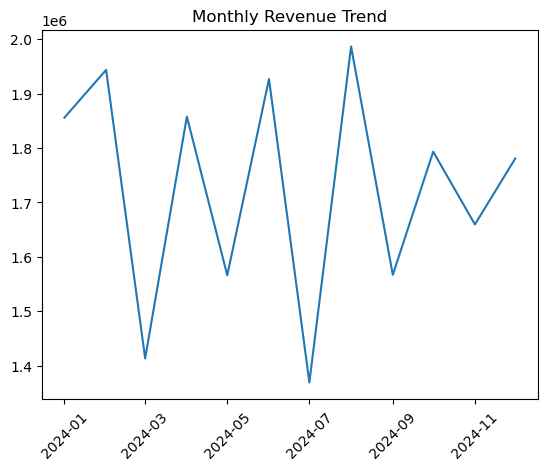

In [221]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

In [232]:
monthly_sales['Revenue'].pct_change()*100

0           NaN
1      4.729146
2    -27.295164
3     31.462557
4    -15.697479
5     23.038371
6    -28.958724
7     45.131547
8    -21.131890
9     14.451175
10    -7.460816
11     7.310849
Name: Revenue, dtype: float64

In [235]:
monthly_sales['Revenue'].pct_change().mean()*100

df.groupby('Month_Name')['Revenue'].sum().sort_values(ascending=False)

Month_Name
August       1986713
February     1943641
June         1926915
April        1857725
January      1855874
October      1793316
December     1780845
November     1659520
September    1566883
May          1566109
March        1413121
July         1368905
Name: Revenue, dtype: int64

In [237]:
print(monthly_sales['Revenue'].pct_change().mean() * 100)
print(monthly_sales['Revenue'].pct_change().std() * 100)

2.3254156129326495
24.72841942473193


In [239]:
Markdown(f"""
### 📈 Sales Trend Analysis

The data shows a **highly volatile pattern**, with a volatility of **{round(monthly_sales['Revenue'].pct_change().std() * 100,2)}%**.

While there is a slight positive average growth of **{round(monthly_sales['Revenue'].pct_change().mean() * 100,2)}%**, this trend is not strong or consistent.

Overall, sales performance appears **unstable** with significant fluctuations across the 12-month period and no clear sustained upward trend.

Given the limited time frame, it is difficult to draw definitive conclusions, but the variability suggests that sales performance may be influenced by irregular factors such as seasonality or external events.

Further analysis would be required to identify the underlying drivers of this variability.

""")


### 📈 Sales Trend Analysis

The data shows a **highly volatile pattern**, with a volatility of **24.73%**.

While there is a slight positive average growth of **2.33%**, this trend is not strong or consistent.

Overall, sales performance appears **unstable** with significant fluctuations across the 12-month period and no clear sustained upward trend.

Given the limited time frame, it is difficult to draw definitive conclusions, but the variability suggests that sales performance may be influenced by irregular factors such as seasonality or external events.

Further analysis would be required to identify the underlying drivers of this variability.



In [240]:
Markdown(f"""
### 📅 Seasonal Opportunities

Lower-performing months such as **July** and **March** may present opportunities for targeted promotional campaigns.

However, further analysis would be required to confirm whether these patterns are consistent over time or driven by one-off factors.
""")


### 📅 Seasonal Opportunities

Lower-performing months such as **July** and **March** may present opportunities for targeted promotional campaigns.

However, further analysis would be required to confirm whether these patterns are consistent over time or driven by one-off factors.


In [241]:
Markdown(f"""
## 🧠 Final Business Insights

The analysis of the dataset provides a comprehensive view of the company's sales performance and key operational dynamics.

### 📊 Performance Overview
The business generates consistent revenue with a profit margin of **{profit_margin}%**, indicating a healthy level of profitability.

### 🏆 Product Strategy
Revenue is relatively well distributed across products, with the top-performing product contributing **{top_1_share}%** of total revenue. This suggests a **low level of product dependency**.

### 🌍 Regional Distribution
Sales are moderately concentrated geographically, with the leading region accounting for **{top_region_share}%** of revenue. This indicates some regional strength without excessive dependency.

### 👤 Sales Team Performance
Sales performance is **well balanced across the team**, with no single salesperson dominating revenue generation. This reduces operational risk and dependency on individuals.

### 🔁 Returns Impact
Returns represent only **{returns_impact}%** of total revenue, indicating that they have a **minimal impact on overall business performance**.

### 📈 Sales Trend
The analysis reveals a **highly volatile sales pattern**, with a monthly volatility of approximately **{round(monthly_sales['Revenue'].pct_change().std() * 100,2)}%**.

Although there is a slight positive growth trend (**{round(monthly_sales['Revenue'].pct_change().mean() * 100,2)}%**), it is not strong or consistent, suggesting that performance is influenced by irregular factors rather than sustained growth.

### 📅 Opportunities
Lower-performing periods such as **July and March** may present opportunities for targeted promotional strategies. However, further data would be required to confirm whether these patterns are structural or temporary.

---

## 🚀 Key Takeaways

- The business is **profitable and diversified**
- There is **no strong dependency** on products, regions, or salespersons
- Sales performance is **unstable due to high volatility**
- Returns are **not a significant issue**
- There is **potential to optimize performance through better demand management**

---

## 📌 Next Steps

- Investigate drivers of sales volatility (seasonality, campaigns, external factors)
- Explore customer-level data to identify purchasing patterns
- Develop forecasting models to improve planning
- Implement targeted strategies for low-performing periods

""")


## 🧠 Final Business Insights

The analysis of the dataset provides a comprehensive view of the company's sales performance and key operational dynamics.

### 📊 Performance Overview
The business generates consistent revenue with a profit margin of **25.22%**, indicating a healthy level of profitability.

### 🏆 Product Strategy
Revenue is relatively well distributed across products, with the top-performing product contributing **14.14%** of total revenue. This suggests a **low level of product dependency**.

### 🌍 Regional Distribution
Sales are moderately concentrated geographically, with the leading region accounting for **27.02%** of revenue. This indicates some regional strength without excessive dependency.

### 👤 Sales Team Performance
Sales performance is **well balanced across the team**, with no single salesperson dominating revenue generation. This reduces operational risk and dependency on individuals.

### 🔁 Returns Impact
Returns represent only **0.07%** of total revenue, indicating that they have a **minimal impact on overall business performance**.

### 📈 Sales Trend
The analysis reveals a **highly volatile sales pattern**, with a monthly volatility of approximately **24.73%**.

Although there is a slight positive growth trend (**2.33%**), it is not strong or consistent, suggesting that performance is influenced by irregular factors rather than sustained growth.

### 📅 Opportunities
Lower-performing periods such as **July and March** may present opportunities for targeted promotional strategies. However, further data would be required to confirm whether these patterns are structural or temporary.

---

## 🚀 Key Takeaways

- The business is **profitable and diversified**
- There is **no strong dependency** on products, regions, or salespersons
- Sales performance is **unstable due to high volatility**
- Returns are **not a significant issue**
- There is **potential to optimize performance through better demand management**

---

## 📌 Next Steps

- Investigate drivers of sales volatility (seasonality, campaigns, external factors)
- Explore customer-level data to identify purchasing patterns
- Develop forecasting models to improve planning
- Implement targeted strategies for low-performing periods

